# Exploratory Data Analysis on E-Commerce Sales Data

In [1]:
# Library imported

import pandas as pd

In [2]:
# Dataset Imported

df = pd.read_csv('realistic_e_commerce_sales_data.csv')

In [3]:
# Dataset Overview

df.head()

,Customer ID,Gender,Region,Age,Product Name,Category,Unit Price,Quantity,Total Price,Shipping Fee,Shipping Status,Order Date
0,CUST0268,Male,North,NaN,Monitor,Electronics,300.0,5,1500,13.31,Returned,2023-12-08
1,CUST0046,Male,West,22.0,Headphones,Accessories,100.0,2,200,6.93,In Transit,2023-04-09
2,CUST0169,Female,South,54.0,Monitor,Electronics,300.0,1,300,11.31,Returned,2023-08-28
3,CUST0002,Male,North,23.0,Headphones,Accessories,100.0,5,500,12.22,Delivered,2023-01-18
4,CUST0173,Female,South,NaN,Laptop,Electronics,1500.0,3,4500,5.40,Delivered,2023-01-19


In [4]:
# Dataset Size

df.shape

(1000, 12)

In [41]:
# Column Types

df.dtypes

Customer ID                object
Gender                     object
Region                     object
Age                         int64
Product Name               object
Category                   object
Unit Price                float64
Quantity                    int64
Total Price                 int64
Shipping Fee              float64
Shipping Status            object
Order Date         datetime64[ns]
AgeGroup                 category
dtype: object

In [6]:
df.describe

<bound method NDFrame.describe of     Customer ID  Gender Region   Age Product Name     Category  Unit Price  \
0      CUST0268    Male  North   NaN      Monitor  Electronics       300.0   
1      CUST0046    Male   West  22.0   Headphones  Accessories       100.0   
2      CUST0169  Female  South  54.0      Monitor  Electronics       300.0   
3      CUST0002    Male  North  23.0   Headphones  Accessories       100.0   
4      CUST0173  Female  South   NaN       Laptop  Electronics      1500.0   
..          ...     ...    ...   ...          ...          ...         ...   
995    CUST0201  Female  South  49.0   Headphones  Accessories       100.0   
996    CUST0133    Male   East  47.0       Laptop  Electronics      1500.0   
997    CUST0055  Female  North   NaN        Mouse  Accessories        30.0   
998    CUST0023  Female  South  29.0       Laptop  Electronics      1500.0   
999    CUST0040    Male    NaN  29.0   Smartwatch    Wearables       200.0   

     Quantity  Total Price  S

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer ID      1000 non-null   object 
 1   Gender           1000 non-null   object 
 2   Region           950 non-null    object 
 3   Age              900 non-null    float64
 4   Product Name     1000 non-null   object 
 5   Category         1000 non-null   object 
 6   Unit Price       1000 non-null   float64
 7   Quantity         1000 non-null   int64  
 8   Total Price      1000 non-null   int64  
 9   Shipping Fee     1000 non-null   float64
 10  Shipping Status  950 non-null    object 
 11  Order Date       1000 non-null   object 
dtypes: float64(3), int64(2), object(7)
memory usage: 93.9+ KB


In [8]:
# Null Value Check

df.isnull().sum()

Customer ID          0
Gender               0
Region              50
Age                100
Product Name         0
Category             0
Unit Price           0
Quantity             0
Total Price          0
Shipping Fee         0
Shipping Status     50
Order Date           0
dtype: int64

In [9]:
# Duplicated Value Check

df.duplicated().sum()

np.int64(0)

In [10]:
# Fill Missing Values

df['Age'].fillna(df['Age'].median(), inplace = True)

df['Region'].fillna(df['Region'].mode()[0], inplace = True)

df['Shipping Status'].fillna('Unknown', inplace = True)

C:\Users\srish\AppData\Local\Temp\ipykernel_32132\1159961576.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace = True)
C:\Users\srish\AppData\Local\Temp\ipykernel_32132\1159961576.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For

In [29]:
# Converting OrderDate into datetime

df['Order Date'] = pd.to_datetime(df['Order Date'])

In [28]:
# Converting Age from Float to Integer

df['Age'] = df['Age'].astype(int)

In [13]:
df.describe()

,Age,Unit Price,Quantity,Total Price,Shipping Fee,Order Date
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000
mean,46.926000,457.703777,3.008000,1346.600000,12.416390,2023-07-07 19:30:43.200000
min,18.000000,30.000000,1.000000,30.000000,5.000000,2023-01-01 00:00:00
25%,37.000000,50.000000,2.000000,200.000000,8.560000,2023-04-08 00:00:00
50%,49.000000,200.000000,3.000000,600.000000,12.315000,2023-07-12 12:00:00
75%,58.000000,800.000000,4.000000,1500.000000,16.075000,2023-10-12 18:00:00
max,69.000000,3109.560612,5.000000,7500.000000,19.980000,2024-01-03 00:00:00
std,14.257061,537.231434,1.404246,1834.037877,4.412185,NaN


# DESCRIPTIVE STATISTICS

In [14]:
# Descriptive Statistics

num_data = df.select_dtypes(include = 'number')

descriptive_stats = pd.DataFrame({
    'Mean': num_data.mean(),
    'Median': num_data.median(),
    'Mode': num_data.mode().loc[0],
    'Standard Deviation': num_data.std()
})
descriptive_stats

,Mean,Median,Mode,Standard Deviation
Age,46.926000,49.000,49.00,14.257061
Unit Price,457.703777,200.000,300.00,537.231434
Quantity,3.008000,3.000,3.00,1.404246
Total Price,1346.600000,600.000,200.00,1834.037877
Shipping Fee,12.416390,12.315,9.26,4.412185


## OBSERVATION

- The average customer age is approximately 47 years.
- The average quantity purchased per transaction is approximately 3 units.
- Total Price has a mean of 1346.60 and a median of 600, indicating variation in transaction values.
- Unit Price also shows a noticeable difference between its mean and median, suggesting variation in product prices.
- Shipping Fee has a mean of 12.42, which is close to its median of 12.32, indicating relatively consistent shipping charges.

# TIME SERIES ANALYSIS

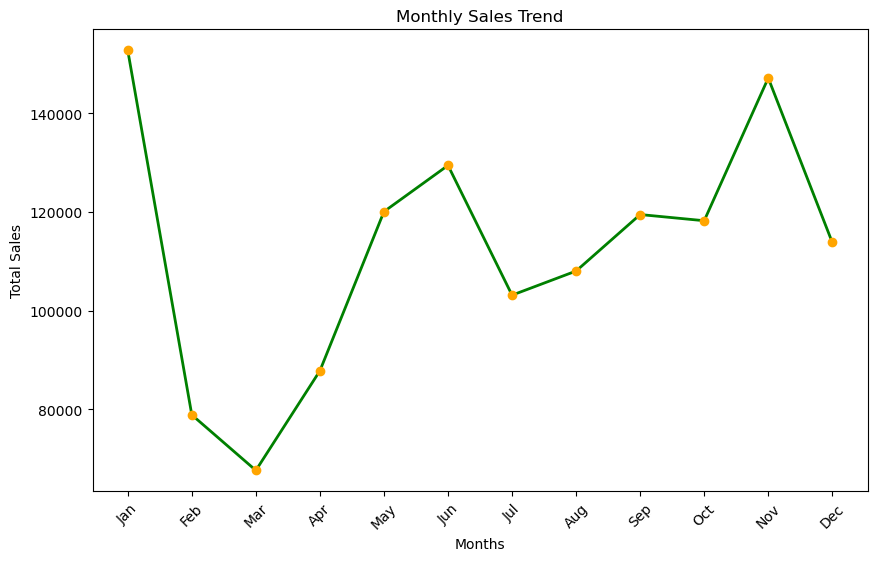

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate total sales for each months
monthly_sales = df.groupby(df['Order Date'].dt.month)['Total Price'].sum()
monthly_sales.index = monthly_sales.index.map({
    1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr',
    5:'May', 6:'Jun', 7:'Jul', 8:'Aug',
    9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'})

# Monthly Sales Trend (Line Chart)
plt.figure(figsize = (10,6))

plt.plot(monthly_sales.index, monthly_sales.values, color = 'green', markerfacecolor = 'orange', markeredgecolor = 'orange', marker = 'o', linewidth = 2)
plt.title('Monthly Sales Trend')
plt.xlabel('Months')
plt.ylabel('Total Sales')
plt.xticks(rotation = 45)
plt.show()

## OBSERVATION

- Sales fluctuate across months, showing clear seasonal demand cycles.  
- Peaks are visible in "January" and "Novembera", indicating strong festive or promotional periods.  
- Noticeable dips occur in "February", "March", and "July", suggesting weaker demand in these months.  
- Insight: Month-wise analysis highlights short-term cycles and helps identify the best months for targeted promotions.

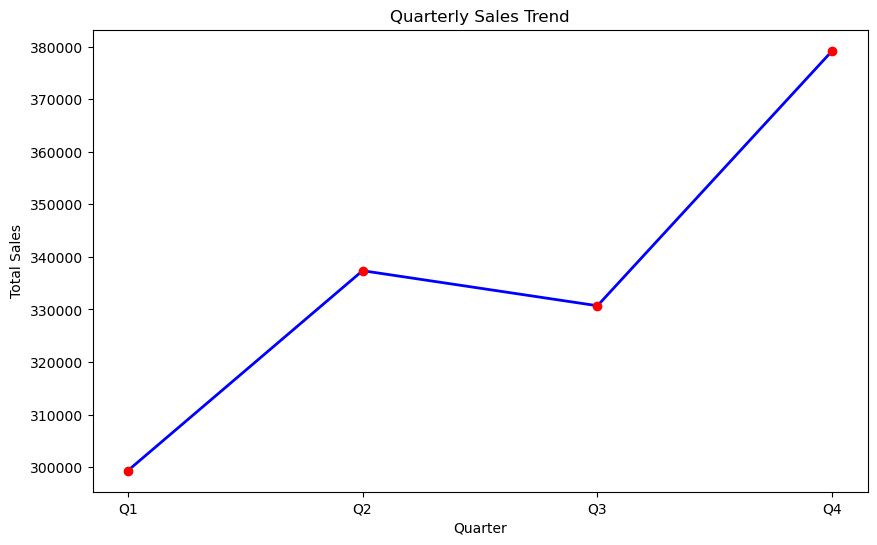

In [31]:
# Calculate total sales for each quarter
quarterly_sales = df.groupby(df['Order Date'].dt.quarter)['Total Price'].sum()
quarterly_sales.index = quarterly_sales.index.map({1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'})

# Quarterly Sales Trend (Line Chart)
plt.figure(figsize=(10,6))

plt.plot(quarterly_sales.index, quarterly_sales.values, color = 'blue', marker = 'o', markerfacecolor = 'red', markeredgecolor = 'red', linewidth = 2)
plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.show()

## OBSERVATION

- Sales increase from "Q1 to Q2", showing growth momentum in the first half of the year.  
- A slight dip occurs in "Q3", but revenue rises sharply in "Q4", making it the strongest quarter.  
- Insight: Quarterly analysis smooths monthly fluctuations and shows overall growth trajectory, with "Q4" being the most profitable period.

# CUSTOMER DEMOGRAPHICS ANALYSIS

In [32]:
# Create Age Groups
bins = [18,30,45,60,100]
labels = ['18-30','31-45', '46-60', '60+']

df['AgeGroup'] = pd.cut(df['Age'], bins = bins, labels = labels, include_lowest = True)

# Count Distribution of Age Groups
Age_Group_Count = df['AgeGroup'].value_counts().sort_index()
print(Age_Group_Count)

AgeGroup
18-30    177
31-45    228
46-60    389
60+      206
Name: count, dtype: int64


C:\Users\srish\AppData\Local\Temp\ipykernel_32132\2094704734.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df, x = 'AgeGroup',  palette = 'viridis', legend = False)


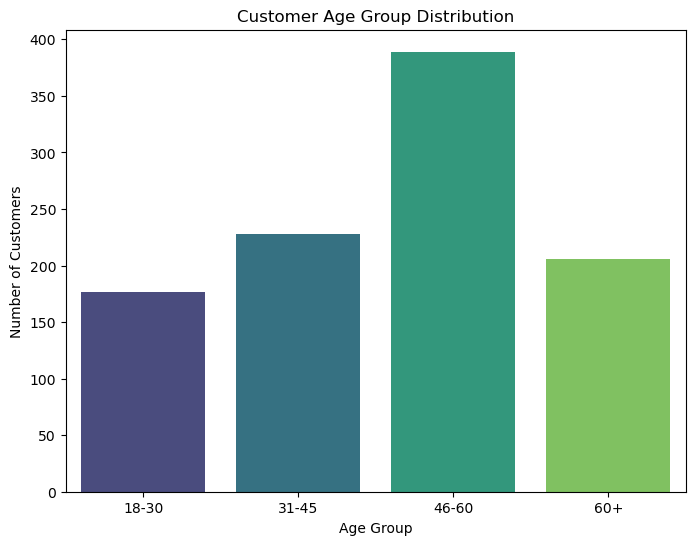

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Customer's Age Group Distribution
plt.figure(figsize = (8,6))

sns.countplot(data = df, x = 'AgeGroup',  palette = 'viridis', legend = False)
plt.title('Customer Age Group Distribution')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.show()

##  OBSERVATION

- The age distribution shows that customers aged "46–60" form the largest customer segment, with 389 customers.
- The "31–45" age group follows with 228 customers, while the "60+" and "18–30" groups account for 206 and 177 customers, respectively.
- Middle-aged customers (31–60) are the core customer base, driving the majority of engagement and revenue.

Gender
Male      524
Female    476
Name: count, dtype: int64


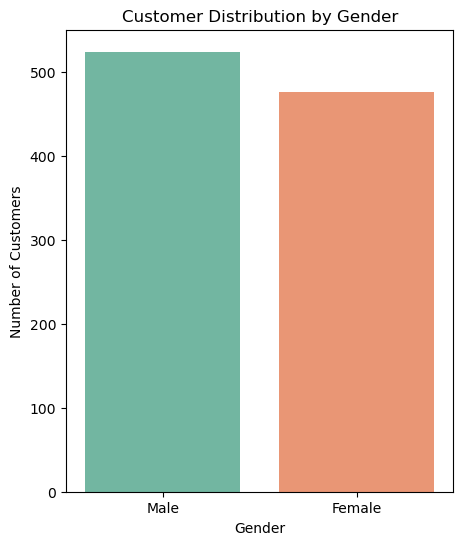

In [34]:
# Customer Demographics - Gender Breakdown
plt.figure(figsize = (5,6))
print(df['Gender'].value_counts())

sns.countplot(data = df, x = 'Gender', hue = 'Gender', palette = 'Set2', legend = False)
plt.title('Customer Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.show()

# Observation

- The dataset contains "524 Male Customers" and "476 Female Customers". 
- The gender distribution is relatively balanced, with male customers representing a slightly larger share of the customer base.

# PRODUCT ANALYSIS

In [35]:
# Top Best-Selling Products

# The data was grouped by Product Name and the Quantity was summed to determine the total number of units sold for each product.
top_products = df.groupby('Product Name')['Quantity'].sum().sort_values(ascending = False)
print(top_products)

Product Name
Monitor       503
Laptop        464
Keyboard      458
Smartphone    442
Mouse         400
Smartwatch    371
Headphones    370
Name: Quantity, dtype: int64


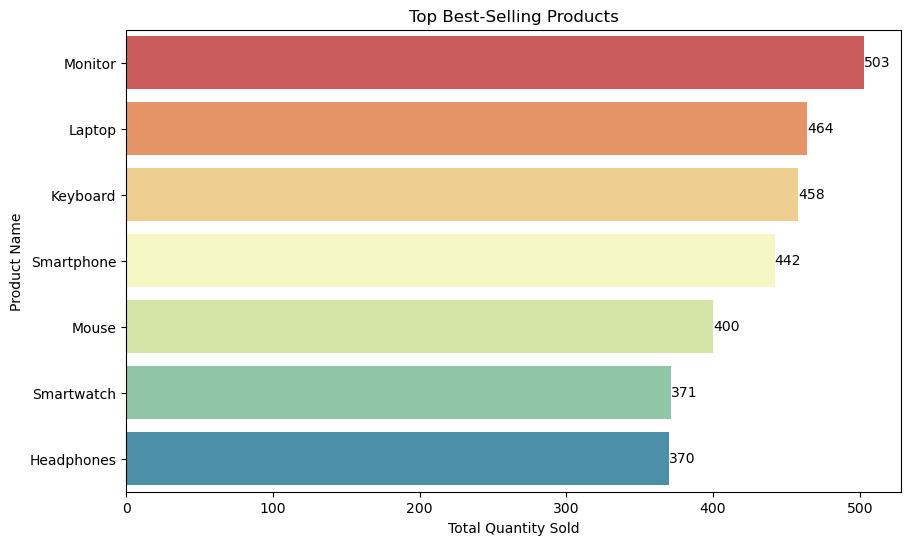

In [36]:
# Best Selling Product Chart
plt.figure(figsize = (10,6))
ax = sns.barplot(x = top_products.values, y = top_products.index, hue = top_products.index, palette = 'Spectral', legend = False)

for container in ax.containers:
    ax.bar_label(container)

plt.title('Top Best-Selling Products')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product Name')
plt.show()

## OBSERVATION 

- "Monitors" are the most popular product, with 503 units sold.
- "Laptops" and "Keyboards" follow closely, showing strong demand for core electronics and accessories.
- "Smartphones" also rank high, confirming their consistent popularity.
- "Accessories(Mouse, Headphones)" and "Wearables(Smartwatch)" contribute significantly to overall sales volume.
- Insight: This indicates that while high-value electronics like "laptops and smartphones" are important, accessories drive large purchase volumes.

In [37]:
# Product Category By Revenue

category_revenue = df.groupby('Category')['Total Price'].sum().sort_values(ascending = False)
print(category_revenue)

Category
Electronics    1200500
Wearables        74200
Accessories      71900
Name: Total Price, dtype: int64


C:\Users\srish\AppData\Local\Temp\ipykernel_32132\1267583254.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x = category_revenue.index, y = category_revenue.values, palette = 'Dark2', legend = False)


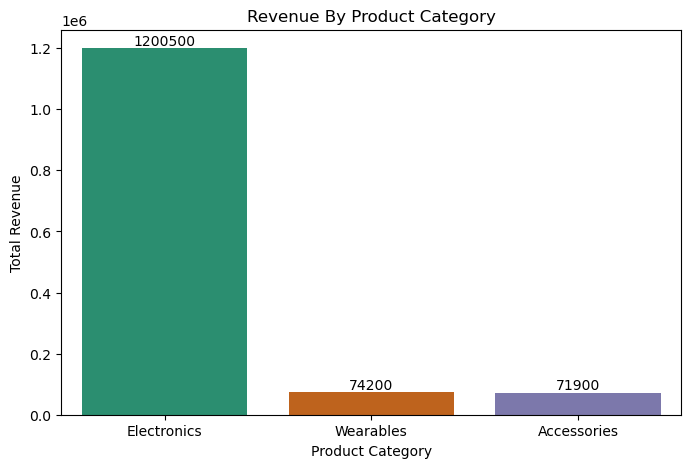

In [23]:
# Bar Chart
plt.figure(figsize = (8,5))
ax = sns.barplot(x = category_revenue.index, y = category_revenue.values, palette = 'Dark2', legend = False)
for container in ax.containers:
    ax.bar_label(container, fmt = '%.0f')
    
plt.title('Revenue By Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')

plt.show()

## OBSERVATION

- Electronics dominate revenue, contributing over ₹1.2M, driven by laptops, smartphones, and monitors.
- Wearables and Accessories contribute much smaller shares (₹74K and ₹72K respectively), showing they are popular but lower-value categories.
- Insight: This highlights that while accessories and wearables drive engagement, electronics are the main profit drivers.

# HEATMAP

In [38]:
# Correlation Matrix of Numerical variables

corr_matrix = df.select_dtypes(include = 'number').corr()
print(corr_matrix)

                   Age  Unit Price  Quantity  Total Price  Shipping Fee
Age           1.000000    0.054737  0.016479     0.038586      0.024008
Unit Price    0.054737    1.000000  0.002678     0.824360      0.016851
Quantity      0.016479    0.002678  1.000000     0.360877      0.045812
Total Price   0.038586    0.824360  0.360877     1.000000      0.003249
Shipping Fee  0.024008    0.016851  0.045812     0.003249      1.000000


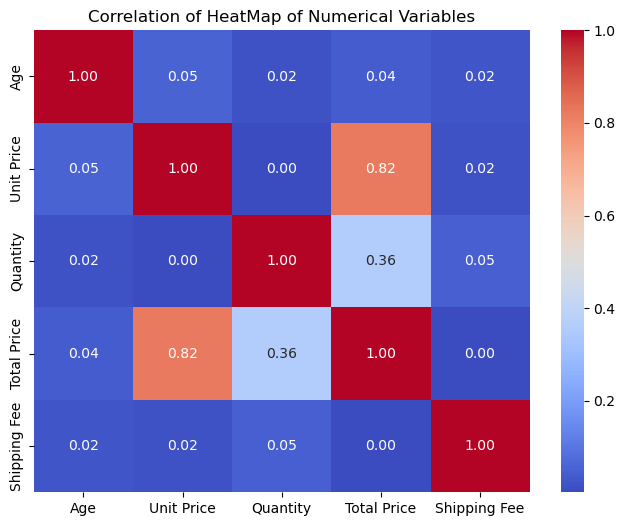

In [39]:
# HeatMap
plt.figure(figsize=(8,6))

sns.heatmap(corr_matrix, annot = True, cmap = 'coolwarm', fmt = '.2f')
plt.title('Correlation of HeatMap of Numerical Variables')
plt.show()

## OBSERVATION

- The heatmap shows a strong positive correlation between "Unit Price" and "Total Price (0.82)". 
- "Quantity" has a moderate positive correlation with "Total Price (0.36)". 
- "Age" and "Shipping Fee" have very weak correlations with the other numerical variables, indicating limited linear relationships.

# ADDITIONAL VISUALIZATION

C:\Users\srish\AppData\Local\Temp\ipykernel_32132\1561823235.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_gender_revenue = df.groupby(['AgeGroup','Gender'])['Total Price'].sum().reset_index()


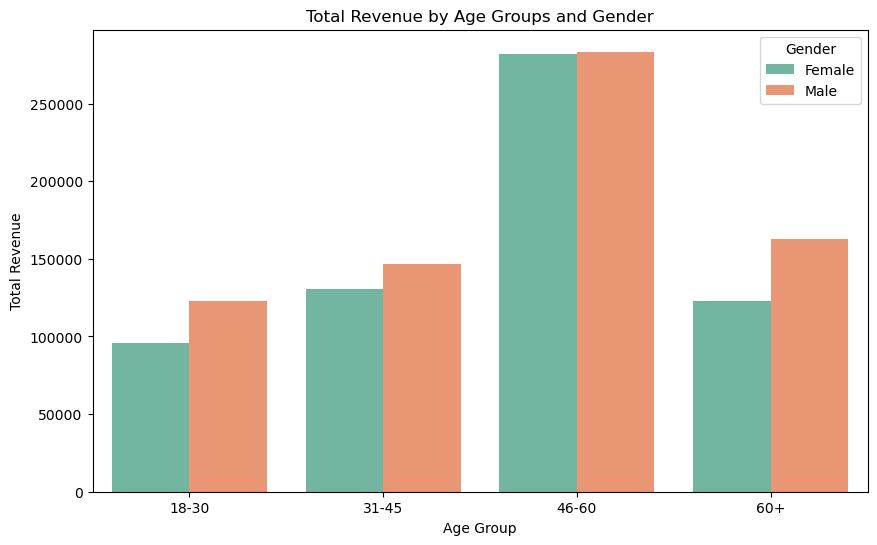

In [40]:
# Group by AgeGroup and Gender

age_gender_revenue = df.groupby(['AgeGroup','Gender'])['Total Price'].sum().reset_index()

# Step 3: Plot Grouped Bar chart (Age vs Gender vs Total revenue)
plt.figure(figsize = (10,6))

sns.barplot(x = 'AgeGroup', y = 'Total Price', hue = 'Gender', data = age_gender_revenue, palette = 'Set2')
plt.title('Total Revenue by Age Groups and Gender')
plt.xlabel('Age Group')
plt.ylabel('Total Revenue')
plt.legend(title = 'Gender', loc = 'upper right')
plt.show()

## OBSERVATION

- The 46–60 age group generates the highest revenue for both male and female customers, making it the strongest revenue-generating customer segment. 
- Male customers generate higher revenue than female customers across all age groups, with the difference being minimal in the 46–60 segment. 
- The 18–30 age group records the lowest revenue for both genders, indicating comparatively lower spending from younger customers.
- The 60+ group shows a decline in revenue compared to 46–60, indicating reduced spending in older demographics.  
- Insight: Spending patterns vary by both age and gender, not just age alone. Middle-aged customers are the most profitable segment.

# Conclusion and Business Recommendations

### Key Findings
The analysis highlights clear differences in customer segments, product demand, category-level revenue, and sales trends.
Customers aged 46–60 represent the largest customer segment and contribute the highest revenue for both genders. 
Electronics is the dominant revenue-generating product category, while Monitor, Laptop, and Keyboard are among the best-selling products by quantity. The sales trend also shows considerable monthly fluctuations, with Q4 achieving the strongest quarterly performance.

### Business Recommendations

1. **Prioritize the 46–60 Customer Segment**  
The 46–60 age group is the largest and highest-revenue customer segment. The business should prioritize this segment through targeted promotions, personalized product recommendations, loyalty programs, and relevant marketing campaigns to strengthen customer retention and increase repeat purchases.

2. **Optimize Inventory for High-Demand Products**  
Monitor, Laptop, Keyboard, Smartphone, and Mouse show strong sales volume. Inventory levels for these products should be monitored closely to reduce stock-out risk. The business can also introduce product bundles and cross-selling offers around these high-demand products to increase the value of each purchase.

3. **Strengthen the Electronics Category**  
Electronics generates significantly higher revenue than Wearables and Accessories. The business should continue investing in its Electronics product range while using cross-selling strategies to promote complementary Wearables and Accessories alongside high-value Electronics purchases.

4. **Use Seasonal Sales Trends for Planning**  
Sales fluctuate considerably across months, while Q4 records the highest quarterly sales. The business should use historical sales patterns to plan inventory, marketing budgets, and promotional campaigns ahead of high-demand periods, while introducing targeted offers during weaker months to improve sales consistency.

5. **Develop Gender-Specific Marketing Strategies**  
 Male customers generate higher revenue across the analyzed age groups. The business can use customer segmentation to develop targeted campaigns while continuing to engage female customers through personalized recommendations and product offers, helping improve overall customer value across both segments.

### Overall Conclusion
The analysis indicates that revenue growth can be supported by focusing on high-value customer segments, maintaining availability of high-demand products, strengthening the Electronics category, and aligning marketing and inventory decisions with seasonal sales patterns. These data-driven strategies can help improve customer retention, optimize inventory management, and support sustainable revenue growth.